In [5]:
import geopandas as gpd

gpkg_path = "../streamlitApp/data/ADE_4-0_GPKG_WGS84G_FRA-ED2025-07-15.gpkg"


gdf_regions = gpd.read_file(gpkg_path, layer="region")   # слой с полигонами регионов
gdf_regions = gdf_regions.to_crs(4326)  # WGS84, на всякий случай
gdf_regions[["code_insee","nom_officiel"]].head()


,code_insee,nom_officiel
0,44,Grand Est
1,32,Hauts-de-France
2,52,Pays de la Loire
3,28,Normandie
4,24,Centre-Val de Loire


In [8]:
import pandas as pd

# твой файл с потреблением по регионам
df = pd.read_csv("../streamlitApp/data/enedis_region_data.csv")

# если в файле несколько лет — выбери, например, 2020 (или нужный)
ANNEE = 2020
df_y = df[df["annee"] == ANNEE].copy()

# приведение кода региона к 2-символьной строке
df_y["code_region"] = df_y["code_region"].astype(str).str.zfill(2)

# агрегат, если в таблице по одному региону несколько строк (например, по секторам)
agg = df_y.groupby("code_region", as_index=False)["conso_totale_mwh"].sum()

# слияние: code_insee в регионах ↔ code_region в твоём csv
gdf_merge = gdf_regions.merge(agg, left_on="code_insee", right_on="code_region", how="left")

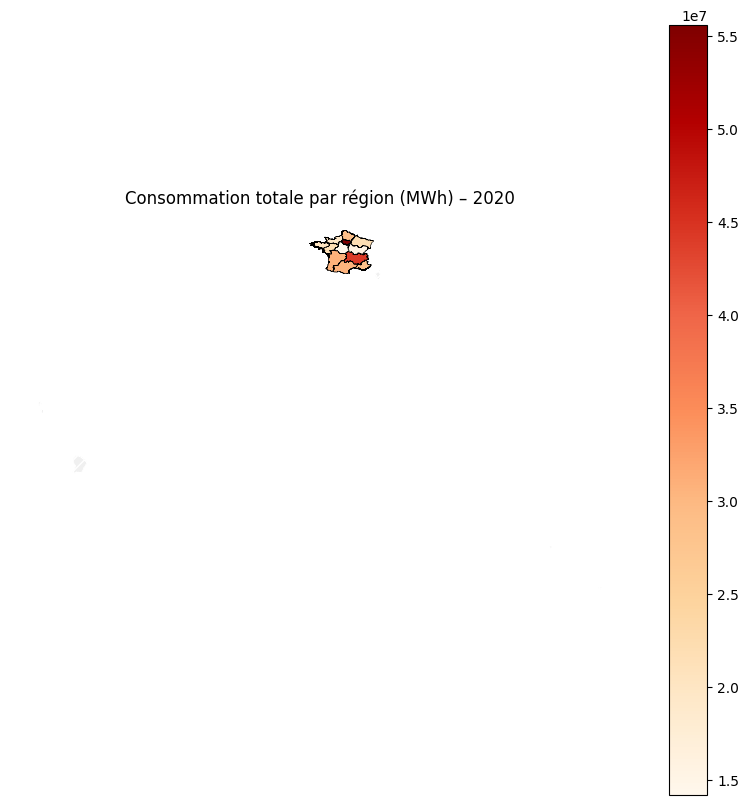

In [9]:
import matplotlib.pyplot as plt

ax = gdf_merge.plot(
    column="conso_totale_mwh",
    cmap="OrRd",
    legend=True,
    figsize=(10,10),
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "#f0f0f0", "edgecolor": "white", "hatch": "///", "label": "No data"}
)
ax.set_title(f"Consommation totale par région (MWh) – {ANNEE}")
ax.set_axis_off()
plt.show()


In [10]:
import folium

# (опционально) упростим геометрию, чтобы карта грузилась быстрее
gdf_web = gdf_merge.copy()
gdf_web["geometry"] = gdf_web.geometry.simplify(0.005, preserve_topology=True)

# экспорт в GeoJSON для folium
geojson_path = "regions_conso.geojson"
gdf_web.to_file(geojson_path, driver="GeoJSON")

# центр карты примерно по Франции
m = folium.Map(location=[46.6, 2.5], zoom_start=5, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=geojson_path,
    data=gdf_web,
    columns=["code_insee", "conso_totale_mwh"],
    key_on="feature.properties.code_insee",
    fill_color="OrRd",
    fill_opacity=0.8,
    line_opacity=0.6,
    legend_name=f"Consommation totale (MWh) – {ANNEE}",
    nan_fill_color="#f0f0f0"
).add_to(m)

# всплывашка с названием и значением
for _, r in gdf_web.iterrows():
    val = r.get("conso_totale_mwh", float("nan"))
    txt = f"<b>{r['nom_officiel']}</b><br>Code: {r['code_insee']}<br>Conso totale: {val:,.0f} MWh" if pd.notna(val) else f"<b>{r['nom_officiel']}</b><br>Нет данных"
    folium.GeoJsonTooltip(fields=["nom_officiel","code_insee"]).add_to(folium.GeoJson(r["geometry"]))
    
m.save("regions_conso_map.html")
print("✅ Сохранено: regions_conso_map.html")


✅ Сохранено: regions_conso_map.html


['canton', 'arrondissement', 'arrondissement_municipal', 'chef_lieu_d_arrondissement', 'chef_lieu_d_arrondissement_municipal', 'chef_lieu_de_canton', 'chef_lieu_de_collectivite_territoriale', 'chef_lieu_de_commune', 'chef_lieu_de_commune_associee_ou_deleguee', 'chef_lieu_de_departement', 'chef_lieu_d_epci', 'chef_lieu_de_region', 'collectivite_territoriale', 'commune', 'commune_associee_ou_deleguee', 'departement', 'epci', 'region', 'info_metadonnees', 'layer_styles']


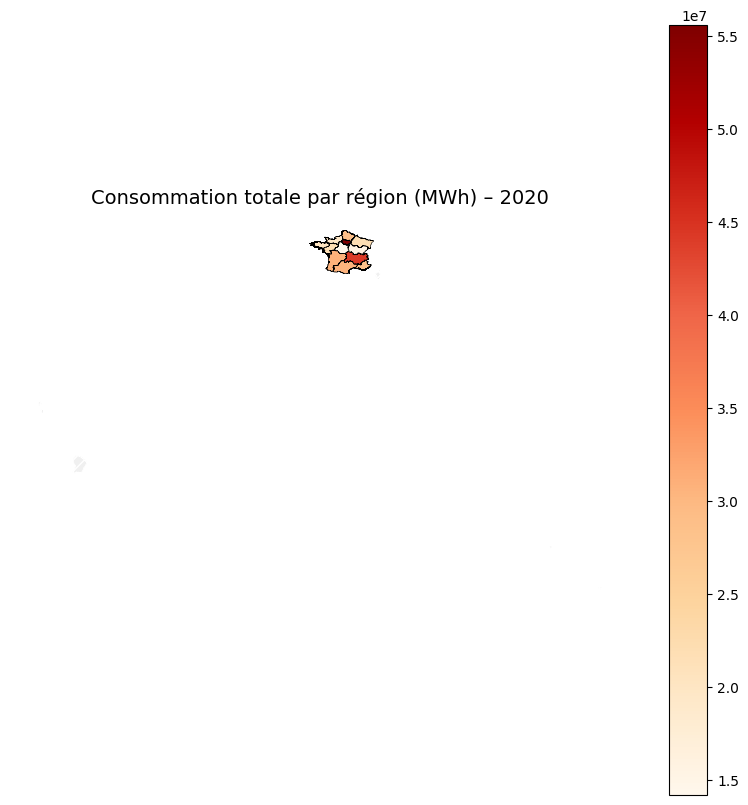

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import fiona

# ==== Параметры ====
gpkg_path = "ADE_4-0_GPKG_WGS84G_FRA-ED2025-07-15.gpkg"
csv_path = "./DataEnedis10_000/enedis_region_data.csv"
ANNEE = 2020  # выбери нужный год

# ==== 1. Читаем слой регионов ====
print(fiona.listlayers(gpkg_path))  # список всех слоёв
gdf_regions = gpd.read_file(gpkg_path, layer="region")
gdf_regions = gdf_regions.to_crs(4326)

# ==== 2. Читаем consommation ====
df = pd.read_csv(csv_path)
df["code_region"] = df["code_region"].astype(str).str.zfill(2)
df_y = df[df["annee"] == ANNEE].copy()

# Агрегация по региону (если в таблице несколько записей для одного региона)
agg = df_y.groupby("code_region", as_index=False)["conso_totale_mwh"].sum()

# ==== 3. Объединяем ====
gdf_merge = gdf_regions.merge(agg, left_on="code_insee", right_on="code_region", how="left")

# ==== 4. Статическая карта ====
fig, ax = plt.subplots(figsize=(10, 10))
gdf_merge.plot(
    column="conso_totale_mwh",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "#f0f0f0", "edgecolor": "white", "hatch": "///", "label": "Нет данных"},
    ax=ax
)
ax.set_title(f"Consommation totale par région (MWh) – {ANNEE}", fontsize=14)
ax.axis("off")
plt.show()


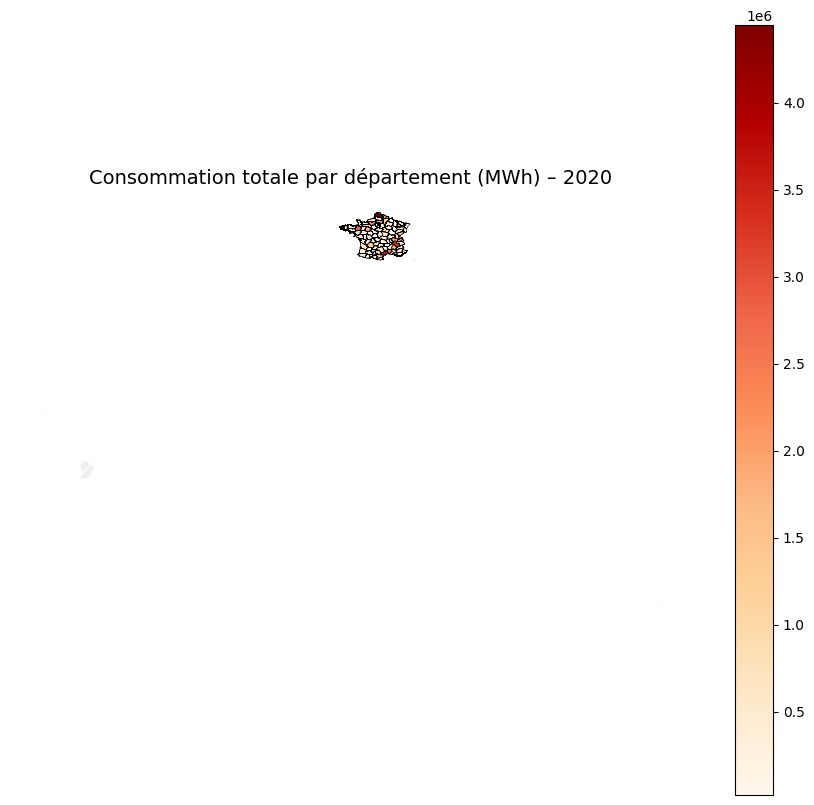

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import fiona

# === Параметры ===
gpkg_path = "ADE_4-0_GPKG_WGS84G_FRA-ED2025-07-15.gpkg"   # твой GeoPackage
csv_path  = "./DataEnedis10_000/enedis_departement_data.csv"                 # твой CSV с потреблением по департаментам
ANNEE = 2020                                              # выбери год анализа
VALUE_COL = "conso_totale_mwh"                            # столбец со значением (замени при необходимости)
CODE_COL  = "code_departement"                            # столбец кода департамента в твоём CSV

# === 0) (опционально) посмотрим, какие слои внутри GPKG ===
# print(fiona.listlayers(gpkg_path))

# === 1) Читаем геометрию департаментов ===
gdf_dept = gpd.read_file(gpkg_path, layer="departement").to_crs(4326)
# Посмотри как называется поле кода в этом слое (обычно 'code_insee')
# print(gdf_dept.columns)

# === 2) Загружаем потребление и нормализуем коды департаментов ===
df = pd.read_csv(csv_path)

def normalize_dept(code):
    """
    Нормализация кода департамента:
    - Сохраняем строково (важно для '2A'/'2B')
    - Для метрополии приводим к 2 символам с ведущим нулём (01..95)
    - Для заморских (971..976) оставляем как есть
    """
    if pd.isna(code):
        return None
    s = str(code).strip().upper()
    # уже корректные случаи
    if s in {"2A", "2B"}: 
        return s
    # заморские департаменты
    if s.isdigit() and 971 <= int(s) <= 976:
        return s
    # остальное — привести к двум символам
    if s.isdigit():
        return s.zfill(2)
    return s  # на всякий случай

df[CODE_COL] = df[CODE_COL].apply(normalize_dept)

# (если в CSV несколько строк на департамент — агрегируем по году)
if "annee" in df.columns:
    df = df[df["annee"] == ANNEE].copy()

agg = df.groupby(CODE_COL, as_index=False)[VALUE_COL].sum()

# === 3) Мёрджим по коду ===
# В слое департаментов код обычно 'code_insee'
key_geo = "code_insee"
gdf_merge = gdf_dept.merge(agg, left_on=key_geo, right_on=CODE_COL, how="left")

# === 4) Рисуем хлороплет ===
fig, ax = plt.subplots(figsize=(11, 10))
gdf_merge.plot(
    column=VALUE_COL,
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "#f0f0f0", "edgecolor": "white", "hatch": "///", "label": "Нет данных"},
    ax=ax
)
title_year = f" – {ANNEE}" if "annee" in df.columns else ""
ax.set_title(f"Consommation totale par département (MWh){title_year}", fontsize=14)
ax.axis("off")
plt.show()


In [2]:
import folium

# Упростим геометрию, чтобы HTML грузился быстрее
gdf_web = gdf_merge.copy()
gdf_web["geometry"] = gdf_web.geometry.simplify(0.01, preserve_topology=True)

geojson_path = "departements_conso.geojson"
gdf_web.to_file(geojson_path, driver="GeoJSON")

m = folium.Map(location=[46.6, 2.5], zoom_start=5, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=geojson_path,
    data=gdf_web,
    columns=[key_geo, VALUE_COL],
    key_on=f"feature.properties.{key_geo}",
    fill_color="OrRd",
    fill_opacity=0.85,
    line_opacity=0.6,
    legend_name=f"Consommation totale (MWh){title_year}",
    nan_fill_color="#f0f0f0"
).add_to(m)

# Добавим всплывающие подсказки с названием и кодом
# Подставь правильное поле названия департамента из gdf_dept (например, 'nom_officiel' или 'nom')
name_field = "nom_officiel" if "nom_officiel" in gdf_web.columns else "nom"
style_func = lambda x: {"fillOpacity": 0, "color": "transparent"}  # слой для tooltip без перекрытия
tooltip = folium.GeoJson(
    gdf_web[[key_geo, name_field, VALUE_COL, "geometry"]],
    style_function=style_func,
    tooltip=folium.GeoJsonTooltip(
        fields=[name_field, key_geo, VALUE_COL],
        aliases=["Département", "Code", "Conso (MWh)"],
        localize=True
    )
)
tooltip.add_to(m)

m.save("departements_conso_map.html")
print("✅ Сохранено: departements_conso_map.html")

✅ Сохранено: departements_conso_map.html
